## Face Recognition — PCA

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pca import PCA
from kmeans import KMeans, fit_cluster_label_mapping, predict_labels_from_clusters
import os

np.random.seed(42)

data = np.load('face_data.npz')
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

os.makedirs('figures', exist_ok=True)

### Fit PCA on Training Data (runs once, saves eigenvalues)

In [2]:
pca = PCA()
pca.fit(X_train)  # computes and saves eigenvalues.npy & eigenvectors.npy

### Load from saved files (skip fit next time)

In [3]:
pca = PCA()
pca.load()
pca.mean = X_train.mean(axis=0)  # mean still needed for projection

### Dimensionality for each variance threshold

In [4]:
alphas = [0.80, 0.85, 0.90, 0.95]

for alpha in alphas:
    k = pca.n_components_for_variance(alpha)
    print(f'α={alpha:.2f} → {k} components')

α=0.80 → 36 components
α=0.85 → 52 components
α=0.90 → 76 components
α=0.95 → 115 components


### Visualize Eigenfaces (top 10 principal components)

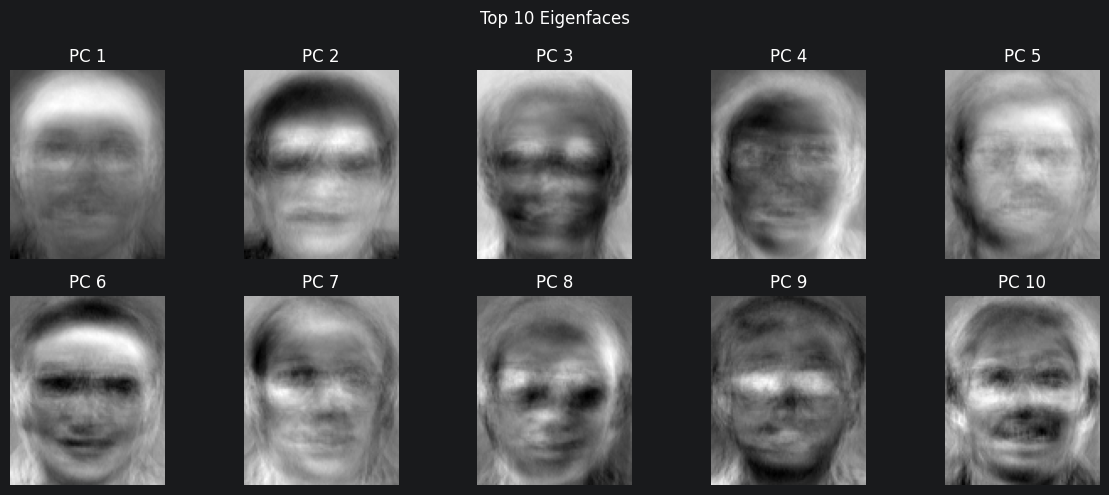

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    eigenface = pca.eigenvectors[i].reshape(112, 92)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PC {i+1}')
    ax.axis('off')
plt.suptitle('Top 10 Eigenfaces')
plt.tight_layout()
plt.savefig('figures/eigenfaces.png', dpi=200, bbox_inches='tight')
plt.show()

### Visualize Sample Faces Reconstructed from PCA subspace

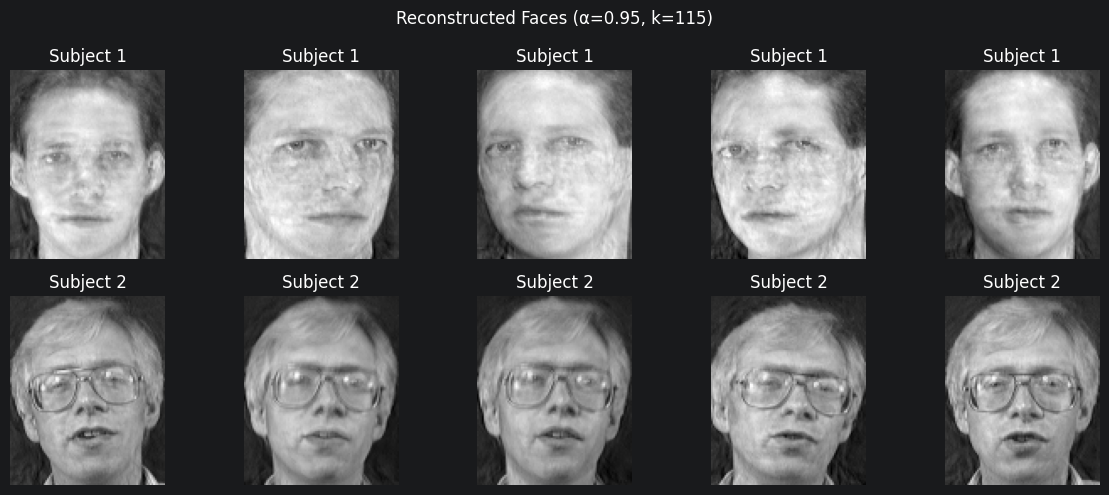

In [6]:
alpha = 0.95
k = pca.n_components_for_variance(alpha)
X_train_pca = pca.project(X_train, alpha)  # (200, k)

# Reconstruct back to image space
X_reconstructed = X_train_pca @ pca.eigenvectors[:k] + pca.mean

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_reconstructed[i].reshape(112, 92), cmap='gray')
    ax.set_title(f'Subject {y_train[i]}')
    ax.axis('off')
plt.suptitle(f'Reconstructed Faces (α={alpha}, k={k})')
plt.tight_layout()
plt.savefig('figures/reconstructions.png', dpi=200, bbox_inches='tight')
plt.show()

### Project Train & Test sets for all thresholds

In [7]:
projected = {}
for alpha in alphas:
    k = pca.n_components_for_variance(alpha)
    projected[alpha] = {
        'X_train': pca.project(X_train, alpha),
        'X_test' : pca.project(X_test,  alpha),
        'k'      : k
    }
    print(f'α={alpha} → X_train: {projected[alpha]["X_train"].shape}, X_test: {projected[alpha]["X_test"].shape}')

α=0.8 → X_train: (200, 36), X_test: (200, 36)
α=0.85 → X_train: (200, 52), X_test: (200, 52)
α=0.9 → X_train: (200, 76), X_test: (200, 76)
α=0.95 → X_train: (200, 115), X_test: (200, 115)


### K-Means grid search on PCA-reduced data (Accuracy + Weighted F1 + Confusion Matrix)

alpha	K	train_acc	test_acc	test_f1_w
0.80	20	0.4750		0.4500		0.3271
0.80	40	0.6900		0.5900		0.5204
0.80	60	0.8500		0.7900		0.7753
0.85	20	0.4700		0.4400		0.3223
0.85	40	0.6950		0.6050		0.5409
0.85	60	0.8050		0.7200		0.7021
0.90	20	0.4600		0.4500		0.3264
0.90	40	0.6600		0.5600		0.4837
0.90	60	0.8050		0.7200		0.6956
0.95	20	0.4600		0.4400		0.3177
0.95	40	0.6100		0.5200		0.4384
0.95	60	0.7950		0.7250		0.6967

Best by TRAIN accuracy:
alpha=0.80, K=60, train_acc=0.8500, test_acc=0.7900, test_f1_w=0.7753

Confusion matrix (test):
[[4 0 0 ... 0 0 0]
 [0 5 0 ... 0 0 0]
 [0 0 4 ... 0 0 0]
 ...
 [0 0 0 ... 5 0 0]
 [0 0 0 ... 0 5 0]
 [0 0 0 ... 0 0 3]]


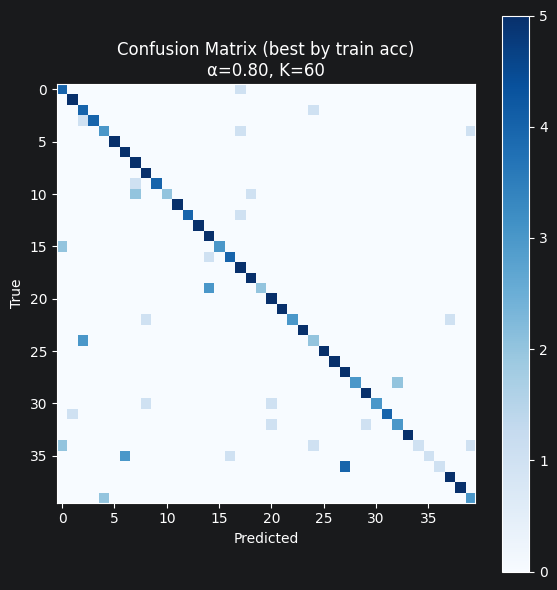

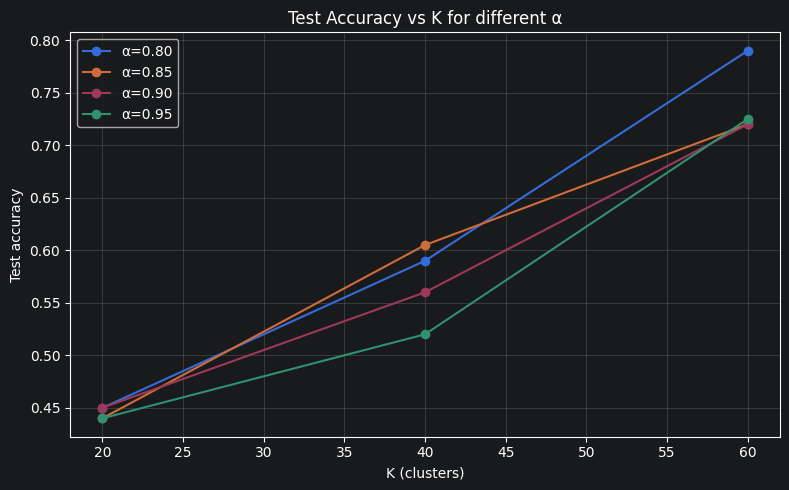

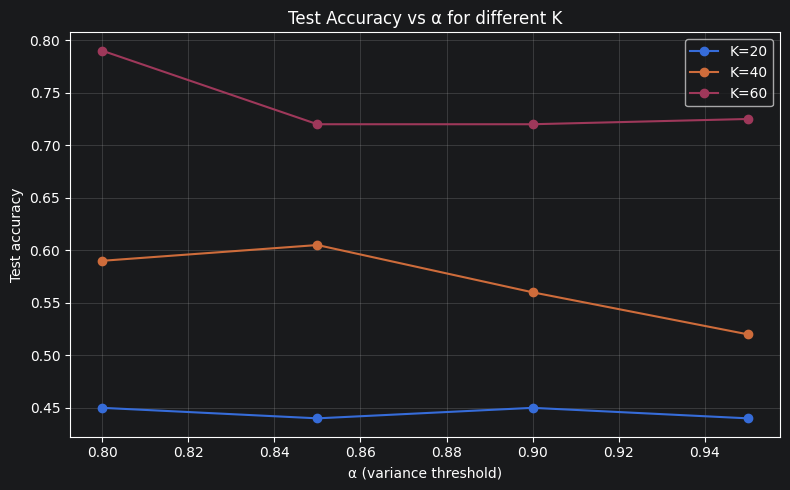

In [8]:
# Simple metrics (no sklearn required)

def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def confusion_matrix(y_true, y_pred, labels):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.asarray(labels)
    label_to_index = {int(label): idx for idx, label in enumerate(labels)}
    cm = np.zeros((labels.size, labels.size), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        if int(yt) in label_to_index and int(yp) in label_to_index:
            cm[label_to_index[int(yt)], label_to_index[int(yp)]] += 1
    return cm


def f1_score_weighted(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels)
    supports = cm.sum(axis=1)
    total = supports.sum()
    f1s = []
    weights = []
    for i in range(len(labels)):
        tp = cm[i, i]
        fp = int(cm[:, i].sum() - tp)
        fn = int(cm[i, :].sum() - tp)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
        weights.append(supports[i])
    if total == 0:
        return 0.0
    return float(np.sum(np.array(f1s) * np.array(weights)) / total)


alphas = [0.80, 0.85, 0.90, 0.95]
Ks = [20, 40, 60]

# Build PCA projections dict if not already created
projected = {}
for alpha in alphas:
    projected[alpha] = {
        'X_train': pca.project(X_train, alpha),
        'X_test': pca.project(X_test, alpha),
        'k': pca.n_components_for_variance(alpha)
    }

labels = np.unique(y_train)

# Grid search: choose best (alpha, K) by TRAIN accuracy
rows = []
best = {'train_acc': -1.0}

for alpha in alphas:
    Xtr = projected[alpha]['X_train']
    Xte = projected[alpha]['X_test']
    for k in Ks:
        km = KMeans(k=k, max_iters=10000, random_state=42)
        tr_clusters = km.fit_predict(Xtr)
        mapping = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred = predict_labels_from_clusters(tr_clusters, mapping, unknown_label=-1)
        train_acc = accuracy_score(y_train, y_tr_pred)

        te_clusters = km.predict(Xte)
        y_te_pred = predict_labels_from_clusters(te_clusters, mapping, unknown_label=-1)
        test_acc = accuracy_score(y_test, y_te_pred)
        test_f1 = f1_score_weighted(y_test, y_te_pred, labels)

        rows.append({
            'alpha': alpha,
            'K': k,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1_weighted': test_f1
        })

        if train_acc > best['train_acc']:
            best = {
                'alpha': alpha,
                'K': k,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'test_f1_weighted': test_f1,
                'y_test_pred': y_te_pred
            }

# Print table
print('alpha\tK\ttrain_acc\ttest_acc\ttest_f1_w')
for r in rows:
    print(f"{r['alpha']:.2f}\t{r['K']}\t{r['train_acc']:.4f}\t\t{r['test_acc']:.4f}\t\t{r['test_f1_weighted']:.4f}")

print('\nBest by TRAIN accuracy:')
print(f"alpha={best['alpha']:.2f}, K={best['K']}, train_acc={best['train_acc']:.4f}, test_acc={best['test_acc']:.4f}, test_f1_w={best['test_f1_weighted']:.4f}")

# Confusion matrix for best config on TEST
cm = confusion_matrix(y_test, best['y_test_pred'], labels)
print('\nConfusion matrix (test):')
print(cm)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (best by train acc)\nα={best['alpha']:.2f}, K={best['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.savefig('figures/cm_kmeans.png', dpi=200, bbox_inches='tight')
plt.show()

# Plot accuracy vs K (one curve per alpha) using TEST accuracy
plt.figure(figsize=(8, 5))
for alpha in alphas:
    accs = [next(r['test_acc'] for r in rows if r['alpha'] == alpha and r['K'] == k) for k in Ks]
    plt.plot(Ks, accs, marker='o', label=f'α={alpha:.2f}')
plt.xlabel('K (clusters)')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs K for different α')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_acc_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

# Plot accuracy vs alpha (one curve per K)
plt.figure(figsize=(8, 5))
for k in Ks:
    accs = [next(r['test_acc'] for r in rows if r['alpha'] == alpha and r['K'] == k) for alpha in alphas]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
plt.xlabel('α (variance threshold)')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs α for different K')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_acc_vs_alpha.png', dpi=200, bbox_inches='tight')
plt.show()


alpha	K	train_acc	test_acc	test_f1_w
0.80	20	0.3850		0.3150		0.2367
0.80	40	0.5550		0.4800		0.3836
0.80	60	0.7400		0.6250		0.6114
0.85	20	0.3850		0.3200		0.2368
0.85	40	0.5700		0.4800		0.3674
0.85	60	0.7250		0.6250		0.6036
0.90	20	0.3850		0.3150		0.2320
0.90	40	0.5600		0.4800		0.3671
0.90	60	0.7250		0.6200		0.5866
0.95	20	0.3750		0.3200		0.2386
0.95	40	0.5500		0.4750		0.3649
0.95	60	0.7200		0.5900		0.5673

Best GMM by TRAIN accuracy:
alpha=0.80, K=60, train_acc=0.7400, test_acc=0.6250, test_f1_w=0.6114

Confusion matrix (GMM test):
[[2 0 0 ... 0 0 0]
 [0 5 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 4 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 1]]


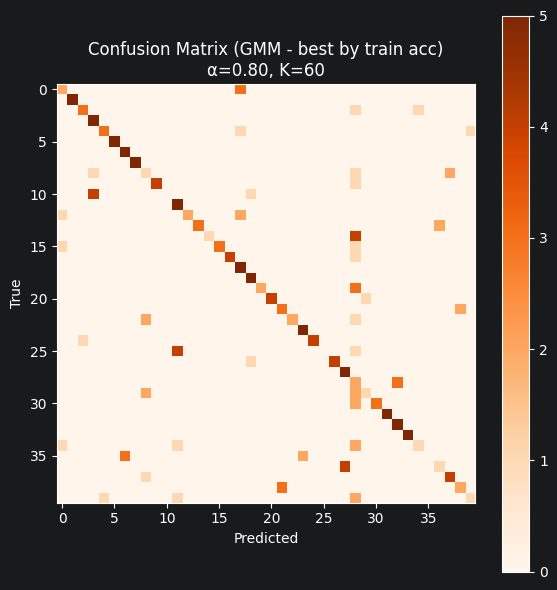

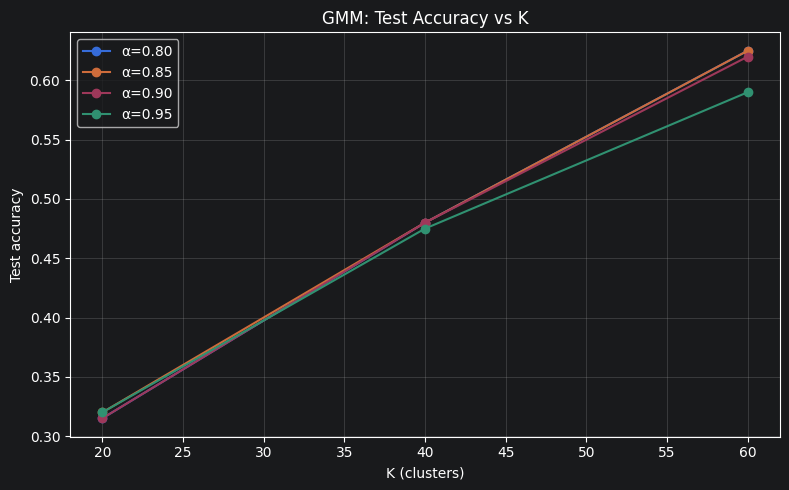

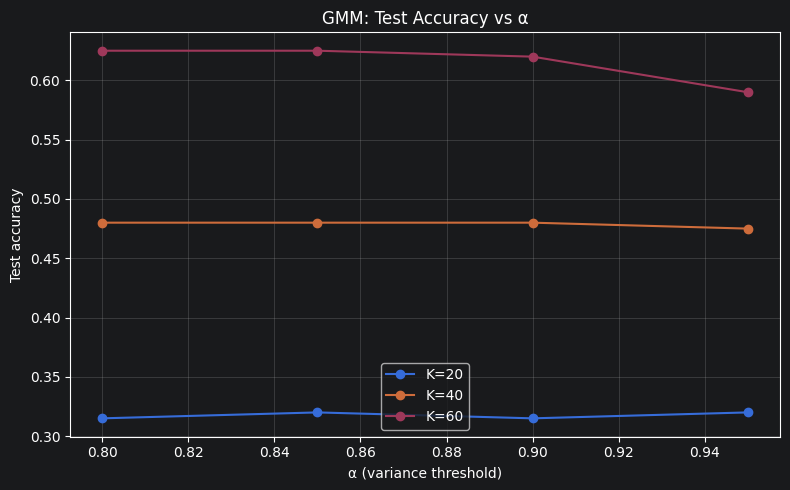


--- Comparison: K-Means vs GMM ---
Best K-Means Test Accuracy: 0.7900
Best GMM Test Accuracy:     0.6250


In [12]:
from gmm import GMM, fit_cluster_label_mapping, predict_labels_from_clusters

gmm_rows = []
best_gmm = {'train_acc': -1.0}

for alpha in alphas:
    Xtr = projected[alpha]['X_train']
    Xte = projected[alpha]['X_test']
    for k in Ks:
        gmm = GMM(k=k, max_iters=50, random_state=42)
        tr_clusters = gmm.fit_predict(Xtr)
        mapping = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred = predict_labels_from_clusters(tr_clusters, mapping, unknown_label=-1)
        train_acc = accuracy_score(y_train, y_tr_pred)

        te_clusters = gmm.predict(Xte)
        y_te_pred = predict_labels_from_clusters(te_clusters, mapping, unknown_label=-1)
        test_acc = accuracy_score(y_test, y_te_pred)
        test_f1 = f1_score_weighted(y_test, y_te_pred, labels)

        gmm_rows.append({
            'alpha': alpha,
            'K': k,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1_weighted': test_f1
        })

        if train_acc > best_gmm['train_acc']:
            best_gmm = {
                'alpha': alpha,
                'K': k,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'test_f1_weighted': test_f1,
                'y_test_pred': y_te_pred
            }

print('alpha\tK\ttrain_acc\ttest_acc\ttest_f1_w')
for r in gmm_rows:
    print(f"{r['alpha']:.2f}\t{r['K']}\t{r['train_acc']:.4f}\t\t{r['test_acc']:.4f}\t\t{r['test_f1_weighted']:.4f}")

print('\nBest GMM by TRAIN accuracy:')
print(f"alpha={best_gmm['alpha']:.2f}, K={best_gmm['K']}, train_acc={best_gmm['train_acc']:.4f}, test_acc={best_gmm['test_acc']:.4f}, test_f1_w={best_gmm['test_f1_weighted']:.4f}")

cm_gmm = confusion_matrix(y_test, best_gmm['y_test_pred'], labels)
print('\nConfusion matrix (GMM test):')
print(cm_gmm)

plt.figure(figsize=(6, 6))
plt.imshow(cm_gmm, cmap='Oranges')
plt.title(f"Confusion Matrix (GMM - best by train acc)\nα={best_gmm['alpha']:.2f}, K={best_gmm['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.savefig('figures/cm_gmm.png', dpi=200, bbox_inches='tight')
plt.show()

# GMM: Test Accuracy vs K (one curve per α)
plt.figure(figsize=(8, 5))
for alpha in alphas:
    accs = [next(r['test_acc'] for r in gmm_rows if r['alpha'] == alpha and r['K'] == k) for k in Ks]
    plt.plot(Ks, accs, marker='o', label=f'α={alpha:.2f}')
plt.xlabel('K (clusters)')
plt.ylabel('Test accuracy')
plt.title('GMM: Test Accuracy vs K')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/gmm_acc_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

# GMM: Test Accuracy vs α (one curve per K)
plt.figure(figsize=(8, 5))
for k in Ks:
    accs = [next(r['test_acc'] for r in gmm_rows if r['alpha'] == alpha and r['K'] == k) for alpha in alphas]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
plt.xlabel('α (variance threshold)')
plt.ylabel('Test accuracy')
plt.title('GMM: Test Accuracy vs α')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/gmm_acc_vs_alpha.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n--- Comparison: K-Means vs GMM ---")
print(f"Best K-Means Test Accuracy: {best['test_acc']:.4f}")
print(f"Best GMM Test Accuracy:     {best_gmm['test_acc']:.4f}")
